<a href="https://colab.research.google.com/github/dv919/RegimeAI/blob/main/RegimeAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
tickers = ["SPY", "QQQ", "GLD", "TLT"]

data = yf.download(
    tickers,
    start="2010-01-01",
    end="2025-01-01",
    auto_adjust=True
)

[*********************100%***********************]  4 of 4 completed


In [4]:
data.head()

Price            Close                                         High  \
Ticker             GLD        QQQ        SPY        TLT         GLD   
Date                                                                  
2010-01-04  109.800003  40.290798  84.796341  55.709526  110.139999   
2010-01-05  109.699997  40.290798  85.020813  56.069328  110.389999   
2010-01-06  111.510002  40.047760  85.080696  55.318710  111.769997   
2010-01-07  110.820000  40.073795  85.439873  55.411819  111.290001   
2010-01-08  111.370003  40.403625  85.724174  55.386951  111.580002   

Price                                               Low                        \
Ticker            QQQ        SPY        TLT         GLD        QQQ        SPY   
Date                                                                            
2010-01-04  40.351559  84.841233  55.889415  109.309998  40.160606  83.434572   
2010-01-05  40.360237  85.058227  56.218200  109.260002  40.065130  84.437198   
2010-01-06  40.403624  85.290198  55.988640  110.410004  39.987003  84.871194   
2010-01-07  40.160593  85.544624  55.604112  110.620003  39.856805  84.684163   
2010-01-08  40.403625  85.761588  55.554431  110.260002  39.865490  85.043292   

Price                        Open                                     Volume  \
Ticker            TLT         GLD        QQQ        SPY        TLT       GLD   
Date                                                                           
2010-01-04  55.566859  109.820000  40.212685  84.078046  55.728134  16224100   
2010-01-05  55.827410  109.879997  40.264760  84.743973  55.858427  14213100   
2010-01-06  55.281494  110.709999  40.273432  84.938531  55.932810  24981900   
2010-01-07  55.281556  111.070000  40.108515  84.923595  55.343586  13609800   
2010-01-08  55.058191  111.519997  39.987004  85.215381  55.523419  15894600   

Price                                     
Ticker           QQQ        SPY      TLT  
Date                                      
2010-01-04  62822800  118944600  2829100  
2010-01-05  62935600  111579900  2841600  
2010-01-06  96033000  116074400  4099600  
2010-01-07  77094100  131091100  2793200  
2010-01-08  88886600  126402800  2910700

In [5]:
data.columns

MultiIndex([( 'Close', 'GLD'),
            ( 'Close', 'QQQ'),
            ( 'Close', 'SPY'),
            ( 'Close', 'TLT'),
            (  'High', 'GLD'),
            (  'High', 'QQQ'),
            (  'High', 'SPY'),
            (  'High', 'TLT'),
            (   'Low', 'GLD'),
            (   'Low', 'QQQ'),
            (   'Low', 'SPY'),
            (   'Low', 'TLT'),
            (  'Open', 'GLD'),
            (  'Open', 'QQQ'),
            (  'Open', 'SPY'),
            (  'Open', 'TLT'),
            ('Volume', 'GLD'),
            ('Volume', 'QQQ'),
            ('Volume', 'SPY'),
            ('Volume', 'TLT')],
           names=['Price', 'Ticker'])

In [6]:
prices = data["Close"].copy()

In [7]:
prices.head()

Ticker,GLD,QQQ,SPY,TLT
Date,,,,
2010-01-04,109.800003,40.290798,84.796341,55.709526
2010-01-05,109.699997,40.290798,85.020813,56.069328
2010-01-06,111.510002,40.047760,85.080696,55.318710
2010-01-07,110.820000,40.073795,85.439873,55.411819
2010-01-08,111.370003,40.403625,85.724174,55.386951


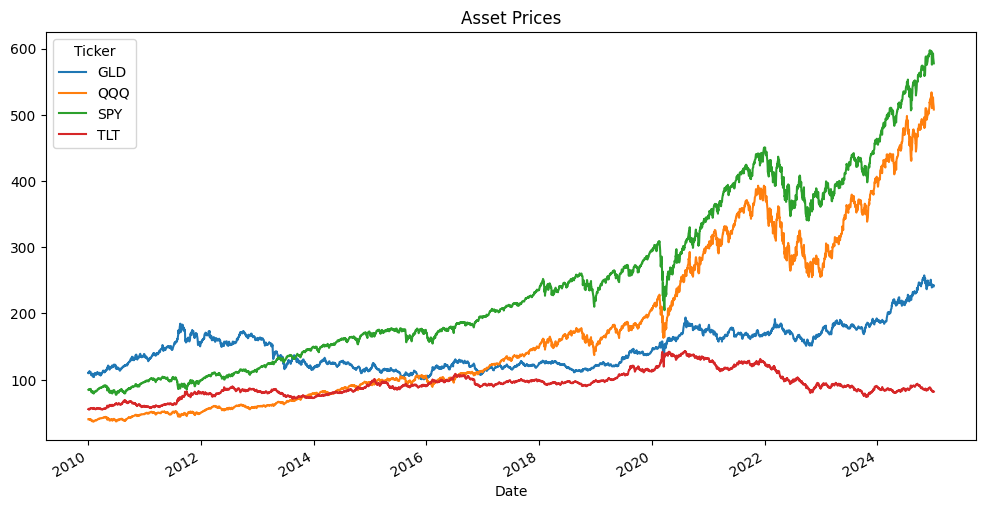

In [8]:
prices.plot(
    figsize=(12,6)
)

plt.title("Asset Prices")
plt.show()

In [9]:
returns = np.log(
    prices / prices.shift(1)
)

In [10]:
returns = returns.dropna()

In [12]:
returns.describe()

Ticker,GLD,QQQ,SPY,TLT
count,3773.000000,3773.000000,3773.000000,3773.000000
mean,0.000210,0.000672,0.000509,0.000103
std,0.009784,0.012903,0.010772,0.009627
min,-0.091905,-0.127592,-0.115887,-0.069012
25%,-0.004808,-0.004751,-0.003716,-0.005695
50%,0.000447,0.001168,0.000682,0.000544
75%,0.005479,0.007322,0.005773,0.005830
max,0.047874,0.081308,0.086731,0.072503


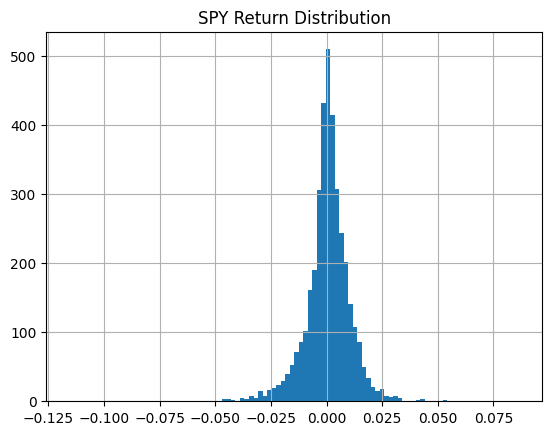

In [13]:
returns["SPY"].hist(
    bins=100
)

plt.title("SPY Return Distribution")
plt.show()

In [14]:
features = pd.DataFrame(index=returns.index)

In [15]:
features["spy_return"] = returns["SPY"]

In [16]:
features["volatility_20"] = (
    returns["SPY"]
    .rolling(20)
    .std()
)

60-Day Volatility

In [17]:
features["volatility_60"] = (
    returns["SPY"]
    .rolling(60)
    .std()
)

In [18]:
features["momentum_30"] = (
    prices["SPY"]
    .pct_change(30)
)

In [19]:
features["momentum_90"] = (
    prices["SPY"]
    .pct_change(90)
)

Moving Average Ratio

In [21]:
ma50 = prices["SPY"].rolling(50).mean()
features["price_ma50_ratio"] = (
    prices["SPY"] / ma50
)

In [20]:
ma200 = prices["SPY"].rolling(200).mean()
features["price_ma200_ratio"] = (
    prices["SPY"] / ma200
)

Bond Market Feature

In [22]:
features["tlt_return"] = returns["TLT"]

Gold Features

In [23]:
features["gld_return"] = returns["GLD"]

Technology Feature

In [24]:
features["qqq_return"] = returns["QQQ"]

Rolling Correlation


In [25]:
features["spy_qqq_corr"] = (
    returns["SPY"]
    .rolling(60)
    .corr(
        returns["QQQ"]
    )
)

Volatility Ratio

In [26]:
features["vol_ratio"] = (
    features["volatility_20"] /
    features["volatility_60"]
)

In [27]:
features = features.dropna()

In [28]:
features.head()

,spy_return,volatility_20,volatility_60,momentum_30,momentum_90,price_ma200_ratio,price_ma50_ratio,tlt_return,gld_return,qqq_return,spy_qqq_corr,vol_ratio
Date,,,,,,,,,,,,
2010-10-18,0.004915,0.007662,0.009786,0.072353,0.094631,1.062446,1.059993,0.008045,0.004478,-0.003697,0.916503,0.782980
2010-10-19,-0.013191,0.008330,0.009886,0.070367,0.075067,1.048288,1.045289,0.006016,-0.031547,-0.009401,0.917360,0.842608
2010-10-20,0.009719,0.008407,0.009951,0.073282,0.087251,1.058248,1.054348,0.002162,0.009257,0.007255,0.917022,0.844848
2010-10-21,0.002203,0.008066,0.009903,0.070704,0.065424,1.060296,1.054897,-0.011946,-0.014188,0.001952,0.916145,0.814505
2010-10-22,0.001861,0.006869,0.009872,0.067309,0.067789,1.061995,1.054922,0.006731,0.002006,0.006801,0.914774,0.695791


In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

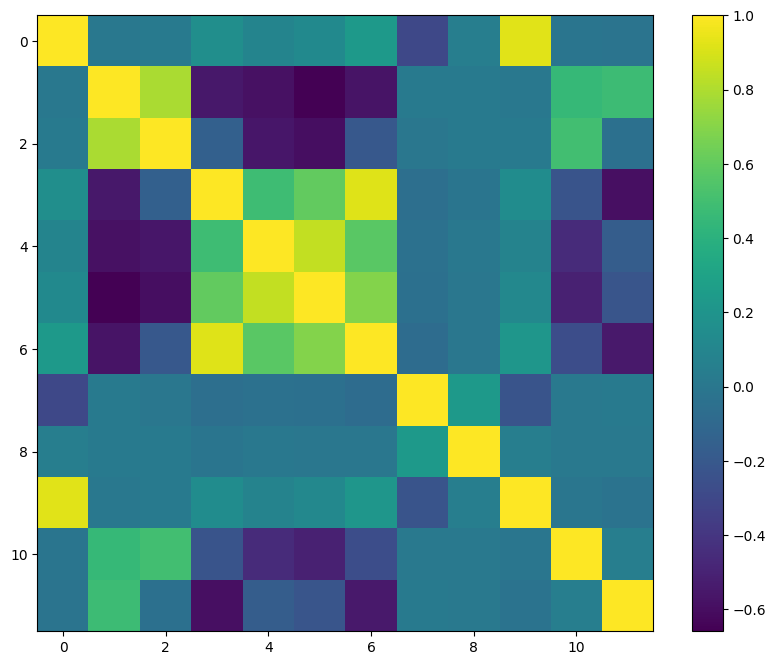

In [30]:
corr_matrix = features.corr()
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.show()

In [31]:
from sklearn.mixture import GaussianMixture

In [32]:
bics = []
aics = []

for k in range(2, 9):

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_scaled)

    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

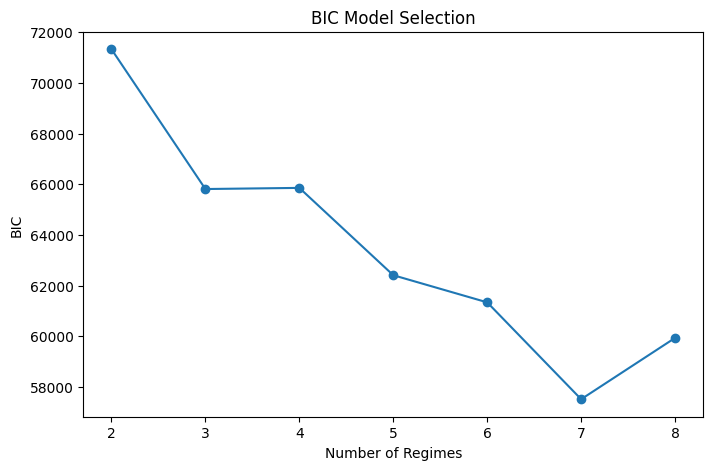

In [33]:
plt.figure(figsize=(8,5))

plt.plot(range(2,9), bics, marker='o')

plt.xlabel("Number of Regimes")
plt.ylabel("BIC")
plt.title("BIC Model Selection")

plt.show()

In [35]:
gmm = GaussianMixture(
    n_components=7,
    random_state=42
)

gmm.fit(X_scaled)

GaussianMixture(n_components=7, random_state=42)

In [36]:
features["regime"] = gmm.predict(X_scaled)

features["regime"].value_counts()

,count
regime,
5,1206
1,605
2,576
6,535
0,439
3,131
4,83


In [37]:
summary = features.groupby("regime").agg({
    "spy_return":"mean",
    "volatility_20":"mean",
    "volatility_60":"mean",
    "momentum_30":"mean",
    "momentum_90":"mean"
})

summary

,spy_return,volatility_20,volatility_60,momentum_30,momentum_90
regime,,,,,
0,0.000231,0.013678,0.014276,-0.001716,-0.035370
1,0.000791,0.006361,0.009503,0.049557,0.084461
2,0.000818,0.004653,0.005004,0.025734,0.071556
3,0.001593,0.016764,0.023278,0.064347,-0.016005
4,-0.001455,0.032711,0.024729,-0.112584,-0.121912
5,0.000518,0.007275,0.007286,0.019319,0.077042
6,0.000194,0.011641,0.009328,-0.007637,0.055009


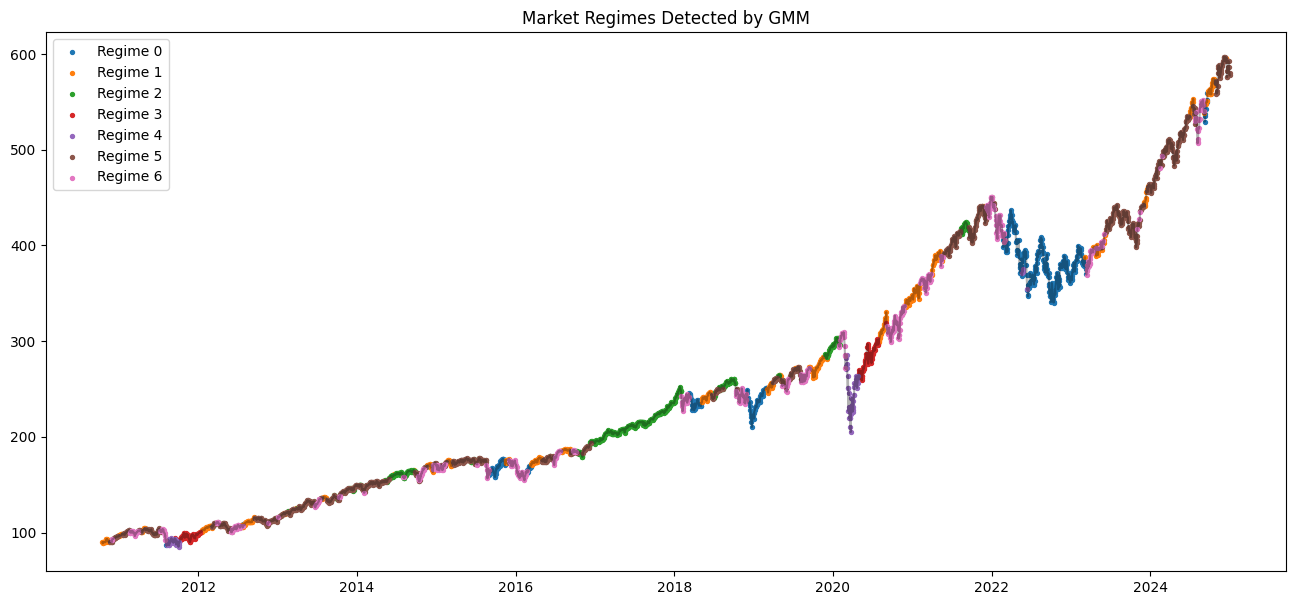

In [38]:
spy_regime = prices.loc[features.index, "SPY"]

plt.figure(figsize=(16,7))

for regime in range(7):

    mask = features["regime"] == regime

    plt.scatter(
        spy_regime.index[mask],
        spy_regime[mask],
        s=8,
        label=f"Regime {regime}"
    )

plt.plot(
    spy_regime,
    color='black',
    alpha=0.3
)

plt.legend()
plt.title("Market Regimes Detected by GMM")
plt.show()

In [39]:
regime_names = {
    0: "Correction",
    1: "Momentum Bull",
    2: "Stable Bull",
    3: "Recovery Rally",
    4: "Crash",
    5: "Late Bull",
    6: "Transition"
}

In [53]:
features["next_regime"] = (
    features["regime"]
    .shift(-1)
)

features = features.dropna()

In [54]:
X = features.drop(
    columns=[
        "regime",
        "next_regime"
    ]
)
y = features["next_regime"]
print(X.shape)
print(y.shape)

(3574, 12)
(3574,)


In [55]:
split_idx = int(
    len(X) * 0.8
)
X_train = X.iloc[:split_idx]
y_train = y.iloc[:split_idx]

In [56]:
X_test = X.iloc[split_idx:]
y_test = y.iloc[split_idx:]

In [57]:
print(len(X_train))
print(len(X_test))

2859
715


In [58]:
from sklearn.ensemble import RandomForestClassifier

In [59]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)
rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

In [60]:
preds = rf.predict(
    X_test
)

In [61]:
from sklearn.metrics import accuracy_score


In [62]:
accuracy_score(
    y_test,
    preds
)

0.7622377622377622

In [63]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(
    y_test,
    preds
)

cm

array([[150,  25,   0,  45,  31,   0,  10],
       [  0,  70,   4,   0,   0,  15,   2],
       [  0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0],
       [  2,   0,   0,   0,   2,   0,   0],
       [  0,   9,   2,   0,   0, 282,   5],
       [  0,   3,   0,   0,   0,  17,  41]])

<Axes: >

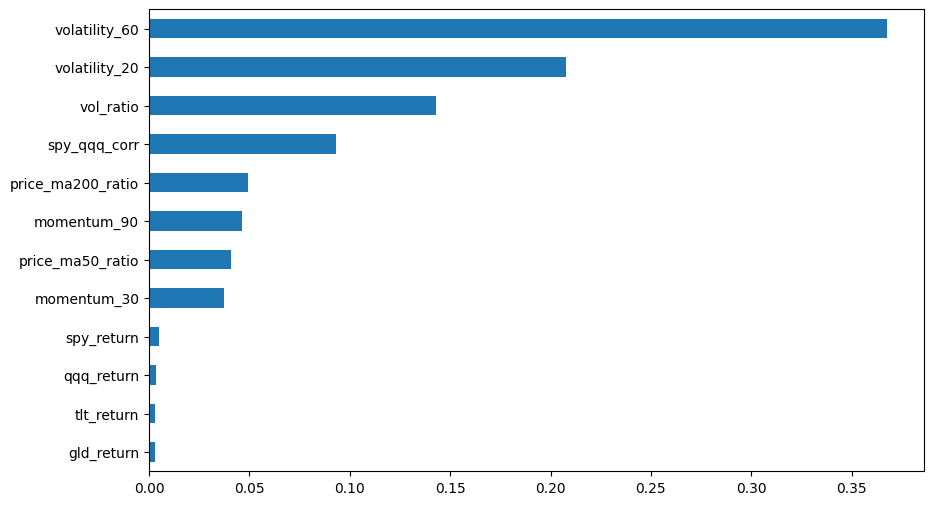

In [64]:
import pandas as pd
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)
importance.sort_values(
    ascending=False
)
importance.sort_values().plot.barh(
    figsize=(10,6)
)

In [65]:
X.columns.tolist()

['spy_return',
 'volatility_20',
 'volatility_60',
 'momentum_30',
 'momentum_90',
 'price_ma200_ratio',
 'price_ma50_ratio',
 'tlt_return',
 'gld_return',
 'qqq_return',
 'spy_qqq_corr',
 'vol_ratio']

In [67]:
from xgboost import XGBClassifier
!pip install xgboost

In [68]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [69]:
xgb.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [70]:
xgb_preds = xgb.predict(
    X_test
)

In [71]:
from sklearn.metrics import accuracy_score

accuracy_score(
    y_test,
    xgb_preds
)

0.7776223776223776

In [72]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
)

importance.sort_values(
    ascending=False
)

,0
volatility_60,0.313750
vol_ratio,0.178706
volatility_20,0.164675
spy_qqq_corr,0.076152
momentum_90,0.056303
price_ma50_ratio,0.047315
price_ma200_ratio,0.047022
momentum_30,0.045721
spy_return,0.019287
tlt_return,0.017777


In [73]:
comparison = pd.DataFrame({
    "Model":["Random Forest","XGBoost"],
    "Accuracy":[0.7622,0.7776]
})

comparison

,Model,Accuracy
0,Random Forest,0.7622
1,XGBoost,0.7776


In [74]:
xgb_preds = xgb.predict(X_test)
test_results = pd.DataFrame(
    index=X_test.index
)

test_results["predicted_regime"] = xgb_preds
test_results["actual_regime"] = y_test

In [75]:
test_returns = returns.loc[
    X_test.index,
    ["SPY","QQQ","TLT","GLD"]
]
allocation_map = {

    1:[0.4,0.5,0.05,0.05],  # Momentum Bull

    2:[0.5,0.4,0.05,0.05],  # Stable Bull

    3:[0.6,0.3,0.05,0.05],  # Recovery

    4:[0.05,0.00,0.70,0.25], # Crash

    0:[0.3,0.2,0.3,0.2],    # Correction

    5:[0.4,0.3,0.2,0.1],    # Late Bull

    6:[0.25,0.25,0.25,0.25] # Transition
}

In [76]:
strategy_returns = []

for date in X_test.index:

    regime = test_results.loc[
        date,
        "predicted_regime"
    ]

    weights = allocation_map[
        regime
    ]

    asset_ret = test_returns.loc[
        date
    ]

    portfolio_ret = (
        asset_ret.values *
        weights
    ).sum()

    strategy_returns.append(
        portfolio_ret
    )

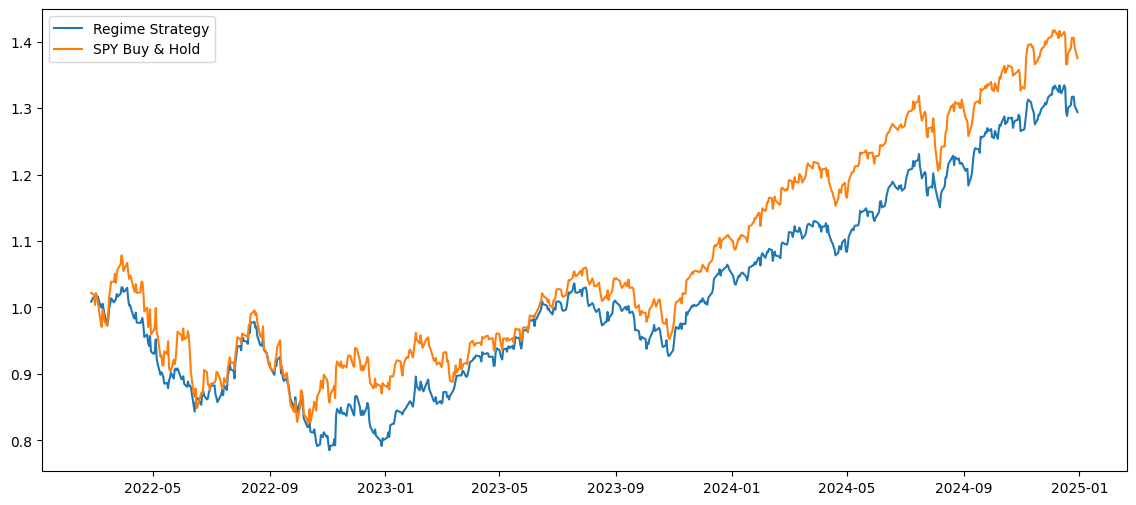

In [78]:
strategy_returns = pd.Series(
    strategy_returns,
    index=X_test.index
)
benchmark_returns = (
    test_returns["SPY"]
)
strategy_equity = (
    1 + strategy_returns
).cumprod()

benchmark_equity = (
    1 + benchmark_returns
).cumprod()
plt.figure(figsize=(14,6))

plt.plot(
    strategy_equity,
    label="Regime Strategy"
)

plt.plot(
    benchmark_equity,
    label="SPY Buy & Hold"
)

plt.legend()

plt.show()

In [80]:
strategy_sharpe = (
    strategy_returns.mean()
    /
    strategy_returns.std()
) * np.sqrt(252)

benchmark_sharpe = (
    benchmark_returns.mean()
    /
    benchmark_returns.std()
) * np.sqrt(252)


np.float64(0.7330500075585703)

In [81]:
strategy_sharpe
benchmark_sharpe

np.float64(0.7330500075585703)

In [82]:
benchmark_sharpe = (
    benchmark_returns.mean()
    /
    benchmark_returns.std()
) * np.sqrt(252)

print("Benchmark Sharpe:", benchmark_sharpe)

Benchmark Sharpe: 0.7330500075585703


In [83]:
def max_drawdown(equity):

    running_max = equity.cummax()

    drawdown = (
        equity /
        running_max
        - 1
    )

    return drawdown.min()

In [84]:
strategy_mdd = max_drawdown(strategy_equity)

benchmark_mdd = max_drawdown(benchmark_equity)

print("Strategy MDD:", strategy_mdd)
print("Benchmark MDD:", benchmark_mdd)


Strategy MDD: -0.237908802091511
Benchmark MDD: -0.23450660790128897


In [85]:
performance = pd.DataFrame({
    "Sharpe":[
        strategy_sharpe,
        benchmark_sharpe
    ],
    "Max Drawdown":[
        strategy_mdd,
        benchmark_mdd
    ]
},
index=[
    "Regime Strategy",
    "SPY Buy & Hold"
])

performance

,Sharpe,Max Drawdown
Regime Strategy,0.716371,-0.237909
SPY Buy & Hold,0.733050,-0.234507
